This notebook picks one random contiguous section from the raw NinaPro DB2 `.mat` files under `data/`, reproduces the same preprocessing used during training, and overlays ground truth with predictions from `outputs_gru` and `outputs_v9_best` for five default MCP-style glove channels.

Default joints:
- `thumb_mcp`
- `index_mcp`
- `middle_mcp`
- `ring_mcp`
- `little_mcp`

If you want a different mapping, edit `DEFAULT_JOINT_SPECS` in the next code cell.

In [1]:
%matplotlib inline

import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import scipy.io
import torch
from scipy.signal import filtfilt

from preprocessing import butter_bandpass, butter_lowpass, segment_data
from model import CNNAttentionImproved
from gru_model import GRUKinematicsRegressor

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
GRU_DIR = BASE_DIR / "outputs_gru"
CNN_DIR = BASE_DIR / "outputs_v9_best"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
FS_EMG = 2000.0
WINDOW_LEN = 400
STEP_LEN = 100
SEGMENT_SECONDS = 12.0
RNG_SEED = 42

DEFAULT_JOINT_SPECS = [
    ("thumb_mcp", 1),
    ("index_mcp", 4),
    ("middle_mcp", 6),
    ("ring_mcp", 9),
    ("little_mcp", 12),
]

random.seed(RNG_SEED)
np.random.seed(RNG_SEED)
torch.manual_seed(RNG_SEED)

plt.rcParams["figure.figsize"] = (14, 12)
plt.rcParams["axes.grid"] = True
print(DEVICE)

cuda


In [2]:
def load_json(path: Path):
    return json.loads(path.read_text(encoding="utf-8"))


def load_scalers(path: Path):
    with np.load(path, allow_pickle=False) as data:
        return {key: np.asarray(data[key]) for key in data.files}


def apply_emg_transform(x: np.ndarray, mode: str) -> np.ndarray:
    if mode == "none":
        return np.asarray(x, dtype=np.float32)
    if mode == "log1p":
        return np.log1p(np.abs(np.asarray(x, dtype=np.float32))).astype(np.float32)
    raise ValueError(f"Unsupported EMG transform: {mode}")


def rms_subframe_sequence(emg_3d: np.ndarray, n_subframes: int) -> np.ndarray:
    arr = np.asarray(emg_3d, dtype=np.float32)
    n, c, t = arr.shape
    n_subframes = int(max(1, n_subframes))
    frame_len = int(max(1, t // n_subframes))
    out = np.zeros((n, c, n_subframes), dtype=np.float32)

    for i in range(n_subframes):
        start = i * frame_len
        end = t if i == (n_subframes - 1) else min(t, start + frame_len)
        chunk = arr[:, :, start:end]
        if chunk.shape[2] == 0:
            chunk = arr[:, :, -1:]
        out[:, :, i] = np.sqrt(np.mean(chunk ** 2, axis=2) + 1e-8)

    return out


def apply_input_scaler(x: np.ndarray, cfg: dict, scalers: dict) -> np.ndarray:
    mode = cfg["data"].get("input_scaler", "none")
    if mode == "none":
        return np.asarray(x, dtype=np.float32)
    if mode != "standard":
        raise ValueError(f"Unsupported input scaler mode: {mode}")

    flat = np.asarray(x, dtype=np.float32).reshape(x.shape[0], -1)
    mean = scalers["x_mean"].reshape(1, -1)
    std = scalers["x_std"].reshape(1, -1)
    return ((flat - mean) / std).reshape(x.shape).astype(np.float32)


def inverse_target_scaler(y: np.ndarray, cfg: dict, scalers: dict) -> np.ndarray:
    mode = cfg["data"].get("target_scaler", "none")
    if mode == "none":
        return np.asarray(y, dtype=np.float32)
    if mode == "standard":
        mean = scalers["y_mean"].reshape(1, -1)
        std = scalers["y_std"].reshape(1, -1)
        return (np.asarray(y, dtype=np.float32) * std + mean).astype(np.float32)
    raise ValueError(f"Unsupported target scaler mode: {mode}")


def preprocess_windows(windows: np.ndarray, cfg: dict, scalers: dict) -> np.ndarray:
    x = apply_emg_transform(windows, cfg["data"].get("emg_transform", "none"))

    input_mode = cfg["data"].get("input_mode", "raw")
    if input_mode == "rms_subframes":
        x = rms_subframe_sequence(x, cfg["data"].get("rms_subframes", 25))
    elif input_mode != "raw":
        raise ValueError(f"Unsupported input mode: {input_mode}")

    return apply_input_scaler(x, cfg, scalers).astype(np.float32)


def build_model_from_checkpoint(model_dir: Path, device: torch.device):
    cfg = load_json(model_dir / "config.json")
    scalers = load_scalers(model_dir / "scaler_params.npz")
    model_cfg = cfg["model"]

    if model_cfg["architecture"] == "CNNAttentionImproved":
        model = CNNAttentionImproved(
            n_ch=int(model_cfg["n_ch"]),
            window_size=int(model_cfg["window_size"]),
            n_joints=int(model_cfg["n_joints"]),
            hidden=int(model_cfg["hidden"]),
            n_attn=int(model_cfg["n_attn"]),
            n_heads=int(model_cfg["n_heads"]),
            dropout=float(cfg["training"]["dropout"]),
        )
    elif model_cfg["architecture"] == "GRUKinematicsRegressor":
        model = GRUKinematicsRegressor(
            n_ch=int(model_cfg["n_ch"]),
            n_joints=int(model_cfg["n_joints"]),
            hidden=int(model_cfg["hidden"]),
            num_layers=int(model_cfg["num_layers"]),
            dropout=float(model_cfg.get("dropout", cfg["training"].get("dropout", 0.0))),
            bidirectional=bool(model_cfg.get("bidirectional", False)),
        )
    else:
        raise ValueError(f"Unsupported architecture: {model_cfg['architecture']}")

    state = torch.load(model_dir / "best_model.pt", map_location=device)
    model.load_state_dict(state)
    model.to(device)
    model.eval()
    return model, cfg, scalers


def find_raw_mat_files(data_dir: Path):
    return sorted(data_dir.rglob("S*_E*_A*.mat"))


def choose_random_raw_file(data_dir: Path) -> Path:
    candidates = []
    for path in find_raw_mat_files(data_dir):
        try:
            mat = scipy.io.loadmat(path, variable_names=["glove"])
        except Exception:
            continue
        if "glove" in mat:
            candidates.append(path)

    if not candidates:
        raise FileNotFoundError(f"No raw NinaPro .mat files with glove data found under {data_dir}")
    return random.choice(candidates)


def load_and_filter_raw_file(mat_path: Path):
    mat = scipy.io.loadmat(mat_path)
    if "emg" not in mat or "glove" not in mat:
        raise KeyError(f"Required variables missing from {mat_path.name}")

    emg = np.asarray(mat["emg"], dtype=np.float32)
    glove = np.asarray(mat["glove"], dtype=np.float32)
    repetition = np.asarray(mat.get("repetition", np.zeros((emg.shape[0], 1))), dtype=np.float32)
    stimulus = np.asarray(mat.get("restimulus", np.zeros((emg.shape[0], 1))), dtype=np.float32)

    n_emg = emg.shape[0]
    n_glove = glove.shape[0]
    n_rep = repetition.shape[0]

    if n_glove != n_emg:
        x_glove = np.linspace(0.0, 1.0, n_glove)
        x_emg = np.linspace(0.0, 1.0, n_emg)
        glove_resampled = np.zeros((n_emg, glove.shape[1]), dtype=np.float32)
        for idx in range(glove.shape[1]):
            glove_resampled[:, idx] = np.interp(x_emg, x_glove, glove[:, idx])
        glove = glove_resampled

    if n_rep != n_emg:
        x_rep = np.linspace(0.0, 1.0, n_rep)
        x_emg = np.linspace(0.0, 1.0, n_emg)
        rep_idx = np.round(np.interp(x_emg, x_rep, np.arange(n_rep))).astype(int)
        rep_idx = np.clip(rep_idx, 0, n_rep - 1)
        repetition = repetition[rep_idx]
        if stimulus.shape[0] == n_rep:
            stimulus = stimulus[rep_idx]

    b_emg, a_emg = butter_bandpass(20.0, 500.0, FS_EMG, order=4)
    filtered_emg = filtfilt(b_emg, a_emg, emg, axis=0).astype(np.float32)

    b_glove, a_glove = butter_lowpass(5.0, FS_EMG, order=2)
    filtered_glove = filtfilt(b_glove, a_glove, glove, axis=0).astype(np.float32)

    return filtered_emg, filtered_glove, stimulus.reshape(-1), repetition.reshape(-1)


def choose_random_active_segment(stimulus: np.ndarray, segment_len: int):
    n = len(stimulus)
    if n <= segment_len:
        return 0, n

    candidates = []
    for start in range(0, n - segment_len, STEP_LEN):
        stop = start + segment_len
        if np.any(stimulus[start:stop] > 0):
            candidates.append(start)

    if not candidates:
        start = random.randint(0, n - segment_len)
        return start, start + segment_len

    start = random.choice(candidates)
    return start, start + segment_len


def apply_window_lag(w_emg, w_ang, w_sti, w_rep, label_times, lag):
    lag = int(lag)
    if lag == 0:
        return w_emg, w_ang, w_sti, w_rep, label_times
    if lag > 0:
        return w_emg[:-lag], w_ang[lag:], w_sti[lag:], w_rep[lag:], label_times[lag:]
    lag = abs(lag)
    return w_emg[lag:], w_ang[:-lag], w_sti[:-lag], w_rep[:-lag], label_times[:-lag]


def run_model(model, cfg, scalers, windows, device):
    x = preprocess_windows(windows, cfg, scalers)
    with torch.no_grad():
        tensor = torch.from_numpy(x).to(device)
        pred = model(tensor).detach().cpu().numpy().astype(np.float32)
    return inverse_target_scaler(pred, cfg, scalers)

In [3]:
raw_file = choose_random_raw_file(DATA_DIR)
filtered_emg, filtered_glove, stimulus, repetition = load_and_filter_raw_file(raw_file)
segment_len = int(SEGMENT_SECONDS * FS_EMG)
start_idx, stop_idx = choose_random_active_segment(stimulus, segment_len)

seg_emg = filtered_emg[start_idx:stop_idx]
seg_glove = filtered_glove[start_idx:stop_idx]
seg_stimulus = stimulus[start_idx:stop_idx]
seg_repetition = repetition[start_idx:stop_idx]

w_emg, w_ang, w_sti, w_rep = segment_data(
    seg_emg,
    seg_glove,
    seg_stimulus.reshape(-1, 1),
    seg_repetition.reshape(-1, 1),
    WINDOW_LEN,
    STEP_LEN,
)

label_times = (np.arange(len(w_emg)) * STEP_LEN + (WINDOW_LEN - 1)) / FS_EMG
raw_file.name, w_emg.shape, w_ang.shape

('S5_E1_A1.mat', (236, 12, 400), (236, 22))

In [4]:
gru_model, gru_cfg, gru_scalers = build_model_from_checkpoint(GRU_DIR, DEVICE)
cnn_model, cnn_cfg, cnn_scalers = build_model_from_checkpoint(CNN_DIR, DEVICE)

common_lag = int(gru_cfg["data"].get("train_target_lag", 0))
if int(cnn_cfg["data"].get("train_target_lag", 0)) != common_lag:
    raise RuntimeError("GRU and CNN checkpoints use different train_target_lag values.")

lagged_emg, gt_angles, lagged_stimulus, lagged_repetition, lagged_times = apply_window_lag(
    w_emg, w_ang, w_sti, w_rep, label_times, common_lag
)

gru_pred = run_model(gru_model, gru_cfg, gru_scalers, lagged_emg, DEVICE)
cnn_pred = run_model(cnn_model, cnn_cfg, cnn_scalers, lagged_emg, DEVICE)

print(f"Raw file: {raw_file}")
print(f"Segment start: {start_idx / FS_EMG:.2f}s | stop: {stop_idx / FS_EMG:.2f}s")
print(f"Windows after lag alignment: {lagged_emg.shape[0]}")
print(f"Active labels in segment: {np.unique(lagged_stimulus.astype(int)).tolist()}")

Raw file: c:\Users\NML\Documents\Github\sEMG-model\ninapro\data\DB2_s5\DB2_s5\S5_E1_A1.mat
Segment start: 182.40s | stop: 194.40s
Windows after lag alignment: 235
Active labels in segment: [0, 4]


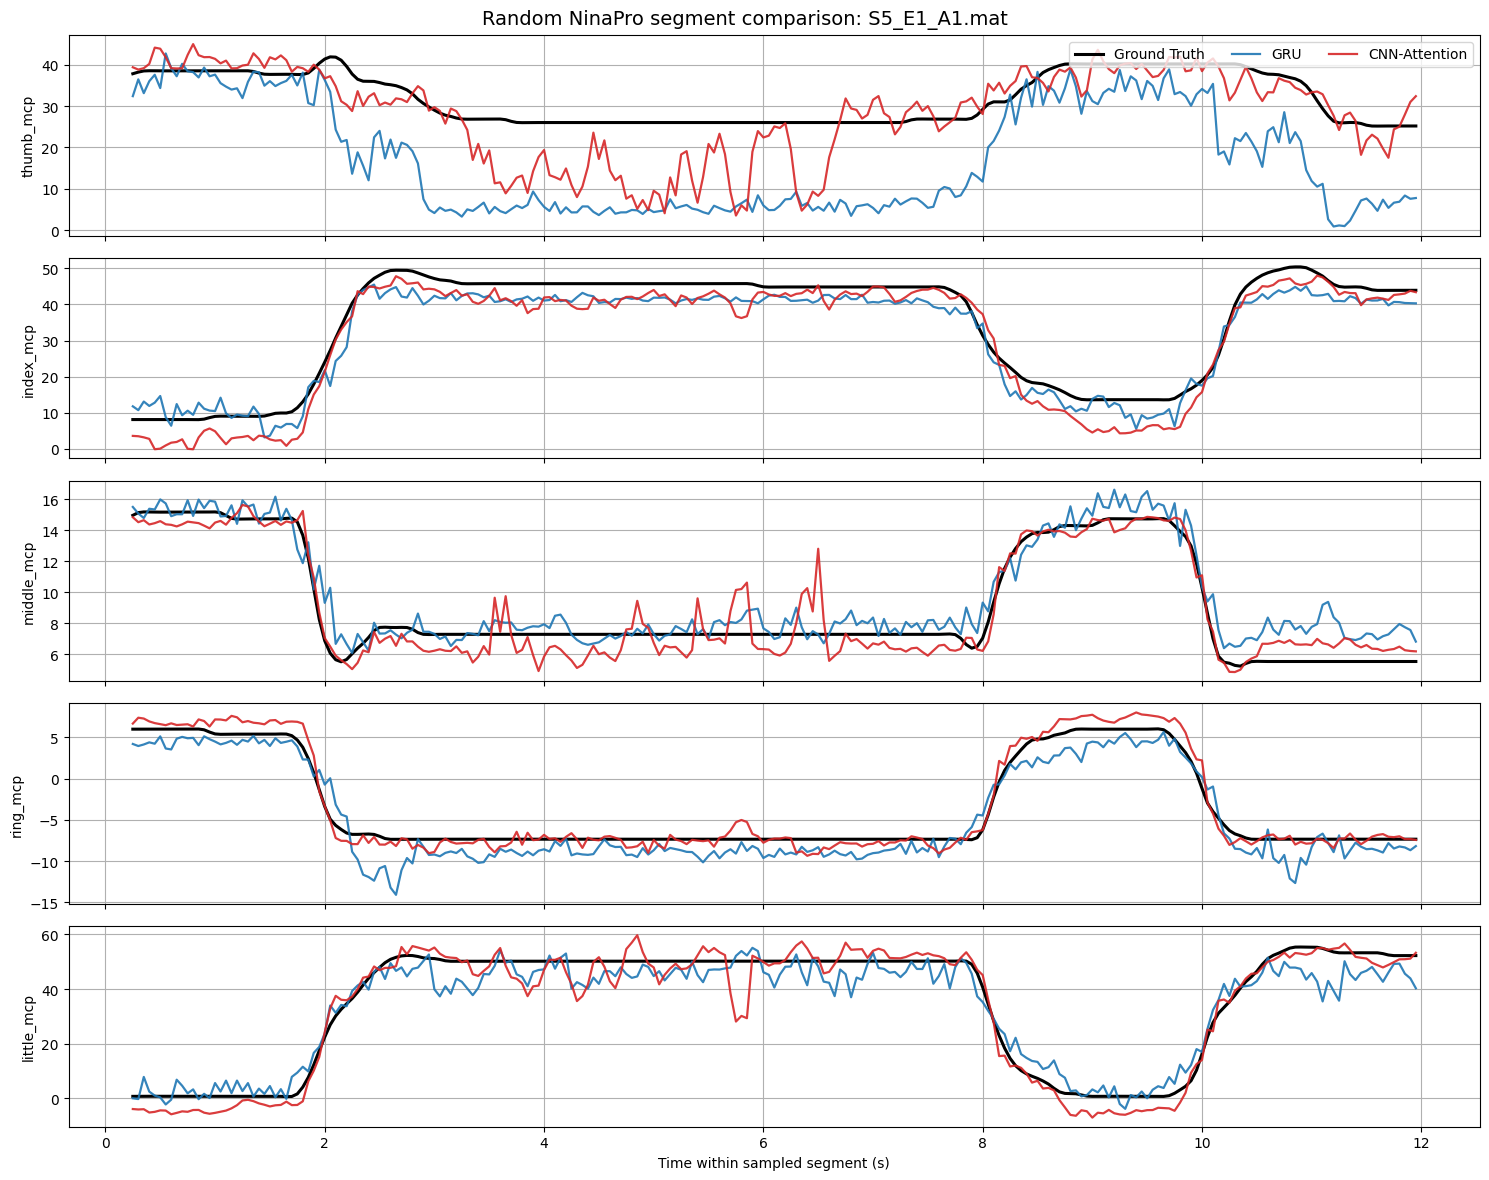

In [5]:
fig, axes = plt.subplots(len(DEFAULT_JOINT_SPECS), 1, sharex=True, figsize=(15, 12))
fig.suptitle(f"Random NinaPro segment comparison: {raw_file.name}", fontsize=14)

for ax, (joint_name, joint_idx) in zip(axes, DEFAULT_JOINT_SPECS):
    ax.plot(lagged_times, gt_angles[:, joint_idx], label="Ground Truth", linewidth=2.2, color="black")
    ax.plot(lagged_times, gru_pred[:, joint_idx], label="GRU", linewidth=1.6, color="#1f77b4", alpha=0.9)
    ax.plot(lagged_times, cnn_pred[:, joint_idx], label="CNN-Attention", linewidth=1.6, color="#d62728", alpha=0.9)
    ax.set_ylabel(joint_name)

axes[0].legend(loc="upper right", ncols=3)
axes[-1].set_xlabel("Time within sampled segment (s)")
plt.tight_layout()
plt.show()

In [6]:
summary_rows = []
for joint_name, joint_idx in DEFAULT_JOINT_SPECS:
    gt = gt_angles[:, joint_idx]
    pred_gru = gru_pred[:, joint_idx]
    pred_cnn = cnn_pred[:, joint_idx]

    gru_rmse = float(np.sqrt(np.mean((pred_gru - gt) ** 2)))
    cnn_rmse = float(np.sqrt(np.mean((pred_cnn - gt) ** 2)))

    def r2_score(pred, target):
        ss_res = np.sum((target - pred) ** 2)
        ss_tot = np.sum((target - target.mean()) ** 2) + 1e-8
        return float(1.0 - ss_res / ss_tot)

    summary_rows.append(
        {
            "joint": joint_name,
            "gru_rmse": gru_rmse,
            "cnn_rmse": cnn_rmse,
            "gru_r2": r2_score(pred_gru, gt),
            "cnn_r2": r2_score(pred_cnn, gt),
        }
    )

summary_rows

[{'joint': 'thumb_mcp',
  'gru_rmse': 16.544116973876953,
  'cnn_rmse': 7.912904262542725,
  'gru_r2': -6.302328586578369,
  'cnn_r2': -0.6704981327056885},
 {'joint': 'index_mcp',
  'gru_rmse': 4.220745086669922,
  'cnn_rmse': 4.760554313659668,
  'gru_r2': 0.9235349893569946,
  'cnn_r2': 0.9027253985404968},
 {'joint': 'middle_mcp',
  'gru_rmse': 1.179558277130127,
  'cnn_rmse': 1.0678999423980713,
  'gru_r2': 0.8884339928627014,
  'cnn_r2': 0.9085562229156494},
 {'joint': 'ring_mcp',
  'gru_rmse': 1.9398446083068848,
  'cnn_rmse': 1.0824345350265503,
  'gru_r2': 0.8833350539207458,
  'cnn_r2': 0.9636746644973755},
 {'joint': 'little_mcp',
  'gru_rmse': 5.761689186096191,
  'cnn_rmse': 4.87669038772583,
  'gru_r2': 0.9300131797790527,
  'cnn_r2': 0.949862003326416}]